In [ ]:
import torch

if torch.cuda.is_available():
    print(
        f"CUDA is available: Using {torch.cuda.device_count()} units of {torch.cuda.get_device_name(0)}"
    )
else:
    print("Using CPU")

Using CPU


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from transformers import BertConfig, BertForMaskedLM
from transformers import Trainer, TrainingArguments
from transformers import AutoModelForSequenceClassification

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.preprocessing import OrdinalEncoder
from sklearn.pipeline import Pipeline

from utils_metrics import evaluate_model_pipeline

from utils_bert import (
    FraudMLMDataset,
    FraudDataCollatorForMLM,
    FraudClassificationDataset,
    compute_metrics,
)

# 1. Data Processing

### Import data

In [ ]:
try:  # Kaggle environment
    df_raw = pd.read_csv(
        "/kaggle/input/datasets/mtalaltariq/paysim-data/paysim dataset.csv"
    )
except:  # Local environment
    df_raw = pd.read_csv("data/paysim_dataset.csv")
df_raw.drop(columns=["nameOrig", "nameDest"], inplace=True)

In [ ]:
df_raw.head()

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,170136.0,160296.36,0.0,0.0,0,0
1,1,PAYMENT,1864.28,21249.0,19384.72,0.0,0.0,0,0
2,1,TRANSFER,181.00,181.0,0.00,0.0,0.0,1,0
3,1,CASH_OUT,181.00,181.0,0.00,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,41554.0,29885.86,0.0,0.0,0,0


### Split Train, Eval, and Test, making sure the fraud distribution is balanced

In [52]:
df_raw_train, df_raw_eval_test = train_test_split(
    df_raw, test_size=0.25, random_state=42, stratify=df_raw["isFraud"]
)

df_raw_eval, df_raw_test = train_test_split(
    df_raw_eval_test,
    test_size=0.6,
    random_state=42,
    stratify=df_raw_eval_test["isFraud"],
)

In [ ]:
labels_train = df_raw_train["isFraud"].to_numpy()
df_raw_train.drop(columns=["isFraud", "isFlaggedFraud"], inplace=True)

labels_eval = df_raw_eval["isFraud"].to_numpy()
df_raw_eval.drop(columns=["isFraud", "isFlaggedFraud"], inplace=True)

labels_test = df_raw_test["isFraud"].to_numpy()
df_raw_test.drop(columns=["isFraud", "isFlaggedFraud"], inplace=True)

### Helpers to turn numerical values into categories / bins
Not only this is necessary to BERT, binning the values also helps in preventing data leakage (where the model would be able to infer accounts based on exact balance values)

In [ ]:
def convert_step_to_hour(step: int) -> str:
    """Convert a step value to an hour string."""
    hour = step % 24
    return f"SYNTH_HOUR_{hour:02d}"

In [55]:
df_raw_train["hour_of_transaction"] = df_raw_train["step"].apply(convert_step_to_hour)
df_raw_eval["hour_of_transaction"] = df_raw_eval["step"].apply(convert_step_to_hour)
df_raw_test["hour_of_transaction"] = df_raw_test["step"].apply(convert_step_to_hour)

df_raw_train.drop(columns=["step"], inplace=True)
df_raw_eval.drop(columns=["step"], inplace=True)
df_raw_test.drop(columns=["step"], inplace=True)

In [56]:
VALUE_BINS = [
    -np.inf,
    0,
    10_000,
    50_000,
    100_000,
    250_000,
    500_000,
    750_000,
    1_000_000,
    3_000_000,
    np.inf,
]
VALUE_LABELS = [
    "VALUE_EQUAL_0",
    "VALUE_BETWEEN_0_10K",
    "VALUE_BETWEEN_10K_50K",
    "VALUE_BETWEEN_50K_100K",
    "VALUE_BETWEEN_100K_250K",
    "VALUE_BETWEEN_250K_500K",
    "VALUE_BETWEEN_500K_750K",
    "VALUE_BETWEEN_750K_1M",
    "VALUE_BETWEEN_1M_3M",
    "VALUE_ABOVE_3M",
]


def bin_values_column(series: pd.Series) -> pd.Series:
    """Fast vectorized binning using pd.cut for whole Pandas Series."""
    return pd.cut(series, bins=VALUE_BINS, labels=VALUE_LABELS, right=True)

In [57]:
monetary_cols = [
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest",
]

# Apply binning across columns
binned_df = df_raw[monetary_cols].apply(bin_values_column)

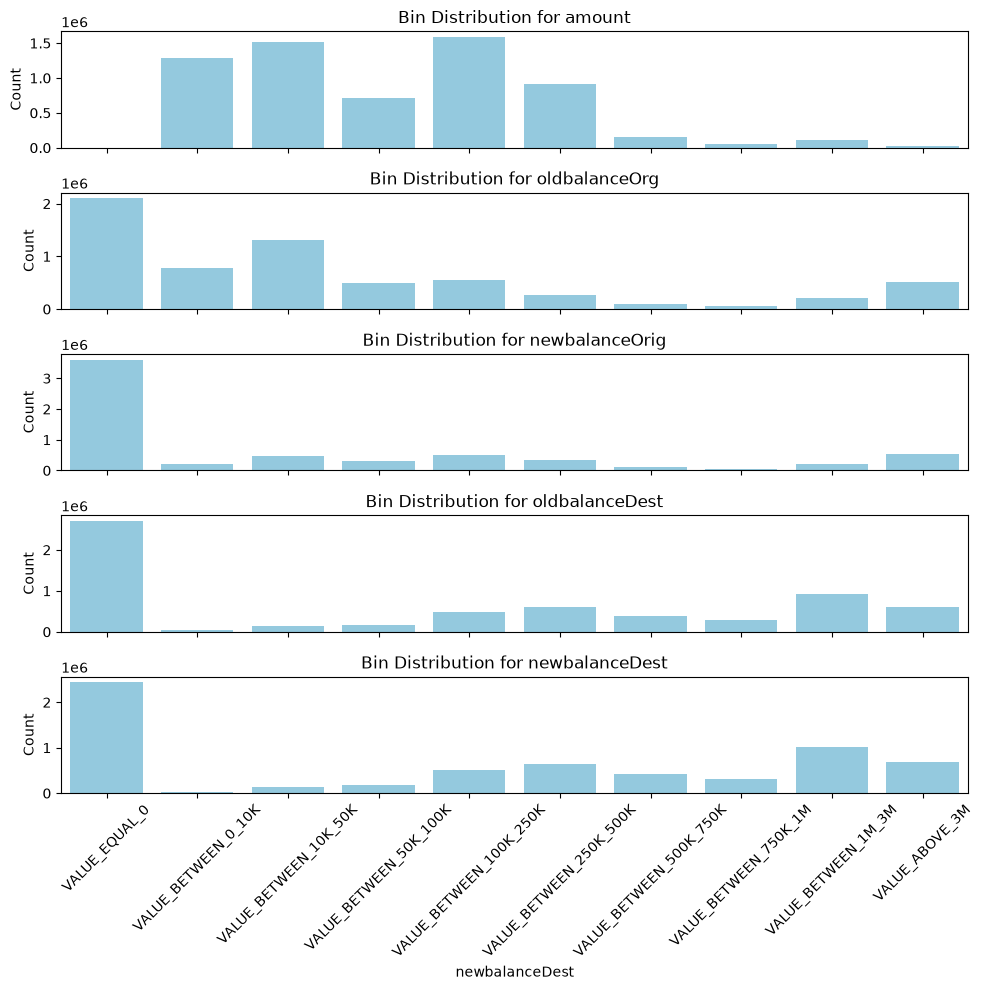

In [58]:
# Plot categorical count plots
fig, axes = plt.subplots(len(monetary_cols), 1, figsize=(10, 10), sharex=True)

for i, col in enumerate(monetary_cols):
    counts = binned_df[col].value_counts().reindex(VALUE_LABELS, fill_value=0)
    sns.barplot(x=counts.index, y=counts.values, ax=axes[i], color="skyblue")
    axes[i].set_title(f"Bin Distribution for {col}")
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [59]:
num_cols_train = df_raw_train.select_dtypes(include=["number"]).columns

for col in num_cols_train:
    df_raw_train[col] = bin_values_column(df_raw_train[col])

num_cols_eval = df_raw_eval.select_dtypes(include=["number"]).columns

for col in num_cols_eval:
    df_raw_eval[col] = bin_values_column(df_raw_eval[col])

num_cols_test = df_raw_test.select_dtypes(include=["number"]).columns

for col in num_cols_test:
    df_raw_test[col] = bin_values_column(df_raw_test[col])

In [60]:
df_raw_train.reset_index(drop=True, inplace=True)
df_raw_eval.reset_index(drop=True, inplace=True)
df_raw_test.reset_index(drop=True, inplace=True)

In [61]:
df_raw_train.head()

,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,hour_of_transaction
0,PAYMENT,VALUE_BETWEEN_10K_50K,VALUE_BETWEEN_50K_100K,VALUE_BETWEEN_10K_50K,VALUE_EQUAL_0,VALUE_EQUAL_0,SYNTH_HOUR_14
1,CASH_IN,VALUE_BETWEEN_100K_250K,VALUE_ABOVE_3M,VALUE_ABOVE_3M,VALUE_BETWEEN_1M_3M,VALUE_BETWEEN_750K_1M,SYNTH_HOUR_20
2,PAYMENT,VALUE_BETWEEN_0_10K,VALUE_BETWEEN_100K_250K,VALUE_BETWEEN_100K_250K,VALUE_EQUAL_0,VALUE_EQUAL_0,SYNTH_HOUR_16
3,CASH_OUT,VALUE_BETWEEN_100K_250K,VALUE_BETWEEN_10K_50K,VALUE_EQUAL_0,VALUE_EQUAL_0,VALUE_BETWEEN_100K_250K,SYNTH_HOUR_20
4,TRANSFER,VALUE_BETWEEN_100K_250K,VALUE_EQUAL_0,VALUE_EQUAL_0,VALUE_BETWEEN_750K_1M,VALUE_BETWEEN_750K_1M,SYNTH_HOUR_18


# 2. Traditional ML

In [ ]:
pipeline_hgb = Pipeline(
    steps=[
        (
            "encoder",
            OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1),
        ),
        (
            "classifier",
            HistGradientBoostingClassifier(
                categorical_features="from_dtype",
                class_weight="balanced",
                random_state=42,
            ),
        ),
    ]
)

# Convert mapped columns to 'category' dtype for HistGradientBoosting
X_train_encoded = df_raw_train.astype("category")
pipeline_hgb.fit(X_train_encoded, labels_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('encoder', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['type','amount','oldbalanceOrg',...,'oldbalanceDest','newbalanceDest', 'hour_of_transaction']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"handle_unknown handle_unknown: {'error', 'use_encoded_value'}, default='error'When set to 'error' an error will be raised in case an unknowncategorical feature is present during transform. When set to'use_encoded_value', the encoded value of unknown categories will beset to the value given for the parameter `unknown_value`. In:meth:`inverse_transform`, an unknown category will be denoted as None... versionadded:: 0.24",'use_encoded_value'
,"unknown_value unknown_value: int or np.nan, default=NoneWhen the parameter handle_unknown is set to 'use_encoded_value', thisparameter is required and will set the encoded value of unknowncategories. It has to be distinct from the values used to encode any ofthe categories in `fit`. If set to np.nan, the `dtype` parameter mustbe a float dtype... versionadded:: 0.24",-1
,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute.",'auto'


In [ ]:
# 1. Convert test set columns to category dtype
X_test_encoded = df_raw_test.astype("category")
X_eval_encoded = df_raw_eval.astype("category")

# 2. Predict probability of fraud (class 1) — Recommended for imbalanced data
y_test_proba = pipeline_hgb.predict_proba(X_test_encoded)[:, 1]
y_eval_proba = pipeline_hgb.predict_proba(X_eval_encoded)[:, 1]

In [67]:
metrics_summary = evaluate_model_pipeline(
    y_eval_true=labels_eval,
    y_eval_probs=y_eval_proba,
    y_test_true=labels_test,
    y_test_probs=y_test_proba,
)

                  MODEL EVALUATION REPORT                   
Selected Threshold (from Eval): 0.95  (Eval F1: 0.5757)
------------------------------------------------------------
OVERALL PERFORMANCE (Test Set):
  • PR-AUC (Avg Precision) : 0.8625
  • ROC-AUC                : 0.9983
  • F1-Score               : 0.5799
  • Precision              : 0.4359
  • Recall                 : 0.8661
------------------------------------------------------------
CONFUSION MATRIX (Test Set):
  • True Negatives  (TN)   : 951,780
  • False Positives (FP)   : 1,381
  • False Negatives (FN)   : 165
  • True Positives  (TP)   : 1,067
------------------------------------------------------------
DETAILED CLASSIFICATION REPORT (Test Set):
              precision    recall  f1-score   support

      Normal     0.9998    0.9986    0.9992    953161
       Fraud     0.4359    0.8661    0.5799      1232

    accuracy                         0.9984    954393
   macro avg     0.7178    0.9323    0.7895    954393
weig

# 3. BERT

### Create vocabulary

In [ ]:
special_tokens = {"[CLS]": 0, "[MASK]": 1, "[SEP]": 2}

transaction_types_tokens = df_raw_train["type"].unique().tolist()
value_bins_tokens = VALUE_LABELS
hour_of_transaction_tokens = df_raw_train["hour_of_transaction"].unique().tolist()

values_vocab = transaction_types_tokens + value_bins_tokens + hour_of_transaction_tokens

print("Number of Special Tokens:", len(special_tokens))
print("Number of Transaction Type Tokens:", len(transaction_types_tokens))
print("Number of Value Bin Tokens:", len(value_bins_tokens))
print("Number of Hour of Transaction Tokens:", len(hour_of_transaction_tokens))

vocab_size = (
    len(special_tokens)
    + len(transaction_types_tokens)
    + len(value_bins_tokens)
    + len(hour_of_transaction_tokens)
)

print("\nTotal Vocabulary Size:", vocab_size)

In [ ]:
values2tokens = {
    value: idx + len(special_tokens) for idx, value in enumerate(values_vocab)
}
token2values = {v: k for k, v in values2tokens.items()}

### Dataset for BERT

In [ ]:
train_dataset = FraudMLMDataset(df_raw_train, values2tokens, special_tokens)
eval_dataset = FraudMLMDataset(df_raw_eval, values2tokens, special_tokens)
test_dataset = FraudMLMDataset(df_raw_test, values2tokens, special_tokens)

### Collator for MLM

In [ ]:
collator = FraudDataCollatorForMLM(
    mask_token_id=special_tokens["[MASK]"],
    cls_token_id=special_tokens["[CLS]"],
    sep_token_id=special_tokens["[SEP]"],
    vocab_size=vocab_size,
    mlm_probability=0.15,
    num_special_tokens=len(special_tokens),
)

### Define and train model

In [ ]:
config = BertConfig(
    vocab_size=vocab_size,
    hidden_size=64,
    num_hidden_layers=2,
    num_attention_heads=2,
    intermediate_size=128,
    max_position_embeddings=df_raw_train.shape[-1] + 2,  # [CLS] and [SEP] tokens
    type_vocab_size=1,
    pad_token_id=None,  # No padding token in this dataset since all sequences are of the same length
)

model = BertForMaskedLM(config)

In [ ]:
training_args = TrainingArguments(
    output_dir="./fraud_bert_mlm",
    num_train_epochs=5,
    per_device_train_batch_size=256,
    per_device_eval_batch_size=512,
    dataloader_num_workers=2,
    dataloader_pin_memory=True,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_steps=50,
    weight_decay=0.01,
    warmup_steps=100,
    report_to="none",
    fp16=True,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    data_collator=collator,
)

In [ ]:
trainer.train()

In [ ]:
trainer.save_model("./fraud_bert_mlm_best")

### Fine tuning on fraud binary classification

In [ ]:
# Path to your best MLM checkpoint directory
mlm_checkpoint_path = "./fraud_bert_mlm_best"

# Load model weights into a Sequence Classification architecture
model = AutoModelForSequenceClassification.from_pretrained(
    mlm_checkpoint_path,
    num_labels=2,  # Binary classification (0: normal, 1: fraud)
)

In [ ]:
supervised_train_dataset = FraudClassificationDataset(
    df_raw_train, values2tokens, special_tokens, labels_train
)
supervised_eval_dataset = FraudClassificationDataset(
    df_raw_eval, values2tokens, special_tokens, labels_eval
)
supervised_test_dataset = FraudClassificationDataset(
    df_raw_test, values2tokens, special_tokens, labels_test
)

In [ ]:
training_args = TrainingArguments(
    output_dir="./fraud_bert_classification",
    num_train_epochs=5,
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,  # Lower learning rate for fine-tuning
    per_device_train_batch_size=256,
    per_device_eval_batch_size=512,
    dataloader_num_workers=2,
    dataloader_pin_memory=True,
    metric_for_best_model="pr_auc",  # Ideal metric for imbalanced fraud datasets
    greater_is_better=True,
    load_best_model_at_end=True,
    fp16=True,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=supervised_train_dataset,  # Dataset yielding 'input_ids', 'attention_mask', and 'labels'
    eval_dataset=supervised_eval_dataset,
    compute_metrics=compute_metrics,  # Custom function for Precision, Recall, F1
)

In [ ]:
trainer.train()

In [ ]:
trainer.save_model("./fraud_bert_classification_best")

In [ ]:
test_results = trainer.predict(supervised_test_dataset)
test_logits = test_results.predictions
test_labels = test_results.label_ids
test_probs = torch.softmax(torch.tensor(test_logits), dim=-1)[:, 1].numpy()

eval_results = trainer.predict(supervised_eval_dataset)
eval_logits = eval_results.predictions
eval_labels = eval_results.label_ids
eval_probs = torch.softmax(torch.tensor(eval_logits), dim=-1)[:, 1].numpy()

# print(test_results.metrics)

In [ ]:
metrics_summary = evaluate_model_pipeline(
    y_eval_true=eval_labels,
    y_eval_probs=eval_probs,
    y_test_true=test_labels,
    y_test_probs=test_probs,
)

### Finetune only head with Frozen BERT

In [ ]:
frozen_model = AutoModelForSequenceClassification.from_pretrained(
    mlm_checkpoint_path,
    num_labels=2,  # Binary classification (0: normal, 1: fraud)
)

# 1. Freeze all base BERT parameters
for param in frozen_model.bert.parameters():
    param.requires_grad = False

# 2. Verify which parameters are still trainable
for name, param in frozen_model.named_parameters():
    if param.requires_grad:
        print(f"Trainable layer: {name}")

In [ ]:
training_args = TrainingArguments(
    output_dir="./fraud_bert_classification_frozen",
    num_train_epochs=5,
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,  # Lower learning rate for fine-tuning
    per_device_train_batch_size=256,
    per_device_eval_batch_size=512,
    dataloader_num_workers=2,
    dataloader_pin_memory=True,
    metric_for_best_model="pr_auc",  # Ideal metric for imbalanced fraud datasets
    greater_is_better=True,
    load_best_model_at_end=True,
    fp16=True,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=supervised_train_dataset,  # Dataset yielding 'input_ids', 'attention_mask', and 'labels'
    eval_dataset=supervised_eval_dataset,
    compute_metrics=compute_metrics,  # Custom function for Precision, Recall, F1
)

In [ ]:
trainer.train()

In [ ]:
trainer.save_model("./fraud_bert_classification_frozen_best")

In [ ]:
test_results = trainer.predict(supervised_test_dataset)
test_logits = test_results.predictions
test_labels = test_results.label_ids
test_probs = torch.softmax(torch.tensor(test_logits), dim=-1)[:, 1].numpy()

eval_results = trainer.predict(supervised_eval_dataset)
eval_logits = eval_results.predictions
eval_labels = eval_results.label_ids
eval_probs = torch.softmax(torch.tensor(eval_logits), dim=-1)[:, 1].numpy()

# print(test_results.metrics)

In [ ]:
metrics_summary = evaluate_model_pipeline(
    y_eval_true=eval_labels,
    y_eval_probs=eval_probs,
    y_test_true=test_labels,
    y_test_probs=test_probs,
)